#Analizą objęto dane z lat 2016–2020, co dało pięć obserwacji czasowych dla każdego województwa, stanowiących podstawę do estymacji przedziałów ufności dla średnich wartości badanych zmiennych. Wyznaczono 95% przedziały ufności dla średniej ilości oraz wartości grzybów i owoców leśnych, z wykorzystaniem rozkładu t-Studenta.

In [3]:
!git clone https://github.com/AleksandraJuchniewicz/Analiza-danych.git

Cloning into 'Analiza-danych'...


In [4]:
%cd Analiza-danych
!ls

c:\Users\kotle\OneDrive\Documents\GitHub\Analiza-danych\Analiza-danych


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
pip install pandas

  Using cached pandas-2.3.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp314-cp314-win_amd64.whl (11.1 MB)
Using cached numpy-2.4.1-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:

pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

df_d = pd.read_csv("bdl_data_dewastacja_.csv")
df_poz=pd.read_csv("bdl_data_pozar_.csv")
df_gaz=pd.read_csv("bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv("bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv("bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv("bdl_datailosc_2024_.csv")
df_war=pd.read_csv("bdl_datawartosc_2024_.csv")
df_las=pd.read_csv("bdl_powlas_2024_.csv")
df_lasch=pd.read_csv("bdl_powlaschro_2024_.csv")

In [8]:
import numpy as np


In [9]:
import math


In [10]:
dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())

df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']


In [11]:
for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {df['Year'].min()}–{df['Year'].max()}")

df1: 2005–2020
df2: 2009–2024
df3: 1998–2024
df4: 1996–2024
df5: 2010–2024
df6: 2009–2024
df7: 2009–2024
df8: 1998–2024
df9: 1998–2024


In [12]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")

df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df9: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [13]:
from functools import reduce

df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)

print(df_all.shape)
print(df_all.head())

(80, 11)
        Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1  MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2  MAŁOPOLSKIE  2018        52.7   236.0  10483040.0  1841.0          52.3   
3  MAŁOPOLSKIE  2019        54.5   190.0   8996236.0  1635.0          53.5   
4  MAŁOPOLSKIE  2020        56.9   176.0   7002044.0  1088.0          53.5   

   Ilosc  Wartosc     P_lasy  P_lasy_ch  
0   22.0    469.0  202140.16   18043.51  
1   16.0    196.7  202078.00   18112.17  
2    9.0    101.0  201366.39   18143.25  
3   27.0    231.9  201241.09   18197.84  
4   18.0    198.6  201200.81   18238.77  


In [14]:
#braki
df_all.isna().sum()
#duikaty
df_all.duplicated(["Region", "Year"]).sum()

np.int64(0)

In [15]:
pip install scipy


  Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.0-cp314-cp314-win_amd64.whl (37.1 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
from scipy.stats import t
import pandas as pd

def confidence_interval(data, confidence=0.95):
    data = data.dropna()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    t_val = t.ppf((1 + confidence) / 2, n - 1)
    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin, n

In [17]:
results_ilosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Ilosc"])
    results_ilosc.append({
        "Region": region,
        "Średnia Ilosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_ilosc = pd.DataFrame(results_ilosc).sort_values("Średnia Ilosc", ascending=False)
print(ci_ilosc)


                 Region  Średnia Ilosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         1576.6        245.58       2907.62  5
9             POMORSKIE         1125.0        519.58       1730.42  5
3              LUBUSKIE          804.6        280.61       1328.59  5
10  WARMIŃSKO-MAZURSKIE          356.2         53.14        659.26  5
4           MAZOWIECKIE          251.2        113.73        388.67  5
8             PODLASKIE          167.6         47.23        287.97  5
0          DOLNOŚLĄSKIE          142.6          0.25        284.95  5
12   ZACHODNIOPOMORSKIE          125.2         65.40        185.00  5
13              ŁÓDZKIE          108.0         12.59        203.41  5
2             LUBELSKIE           47.6        -14.45        109.65  5
1    KUJAWSKO-POMORSKIE           30.4         10.95         49.85  5
5           MAŁOPOLSKIE           18.4         10.04         26.76  5
14              ŚLĄSKIE           17.2          2.34         32.06  5
15       ŚWIĘTOKRZYS

In [18]:
results_wartosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Wartosc"])
    results_wartosc.append({
        "Region": region,
        "Średnia Wartosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_wartosc = pd.DataFrame(results_wartosc).sort_values("Średnia Wartosc", ascending=False)
print(ci_wartosc)

                 Region  Średnia Wartosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         17257.02       4006.70      30507.34  5
9             POMORSKIE         14531.52       6660.39      22402.65  5
3              LUBUSKIE         11741.56       1548.05      21935.07  5
10  WARMIŃSKO-MAZURSKIE          5970.50       -168.19      12109.19  5
8             PODLASKIE          2884.50        357.26       5411.74  5
4           MAZOWIECKIE          2741.58       1426.08       4057.08  5
12   ZACHODNIOPOMORSKIE          1518.34        385.30       2651.38  5
0          DOLNOŚLĄSKIE          1417.96        -64.21       2900.13  5
2             LUBELSKIE           969.60       -553.82       2493.02  5
13              ŁÓDZKIE           833.88        472.99       1194.77  5
1    KUJAWSKO-POMORSKIE           313.02        196.85        429.19  5
5           MAŁOPOLSKIE           239.44         68.95        409.93  5
14              ŚLĄSKIE           221.04         19.76        42

In [19]:
pip install matplotlib


  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.1.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


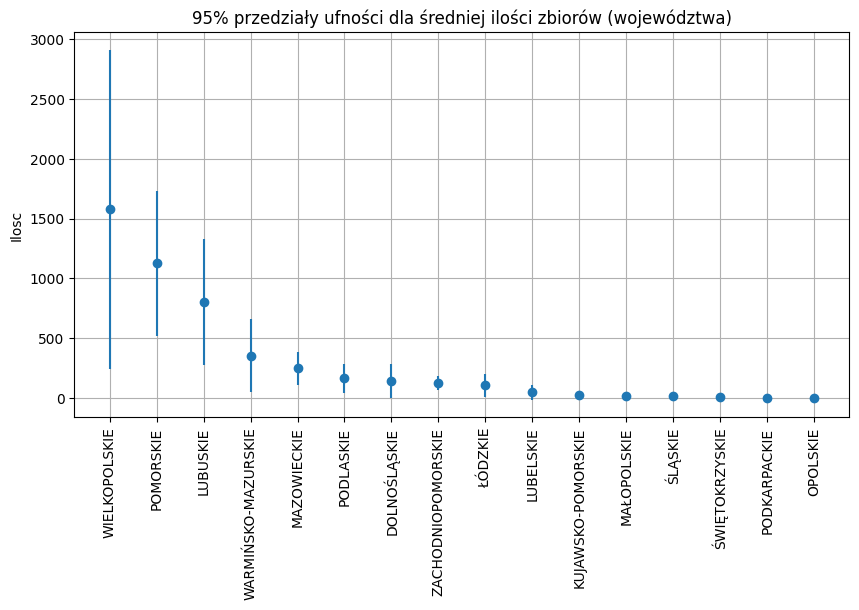

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    ci_ilosc["Region"],
    ci_ilosc["Średnia Ilosc"],
    yerr=[
        ci_ilosc["Średnia Ilosc"] - ci_ilosc["CI 95% dolna"],
        ci_ilosc["CI 95% górna"] - ci_ilosc["Średnia Ilosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej ilości zbiorów (województwa)")
plt.ylabel("Ilosc")
plt.grid(True)
plt.show()


#Wykres przedstawia średnie wartości ilości zbiorów w poszczególnych województwach wraz z 95% przedziałami ufności. Najwyższe poziomy średniej odnotowano w województwie wielkopolskim, a wysokie wartości również w pomorskim i lubuskim. W części regionów przedziały ufności nakładają się, co sugeruje brak istotnych różnic między nimi. Najniższe średnie występują w województwach kujawsko-pomorskim, małopolskim, śląskim, świętokrzyskim, podkarpackim i opolskim, co potwierdza wyraźne zróżnicowanie regionalne badanej zmiennej.

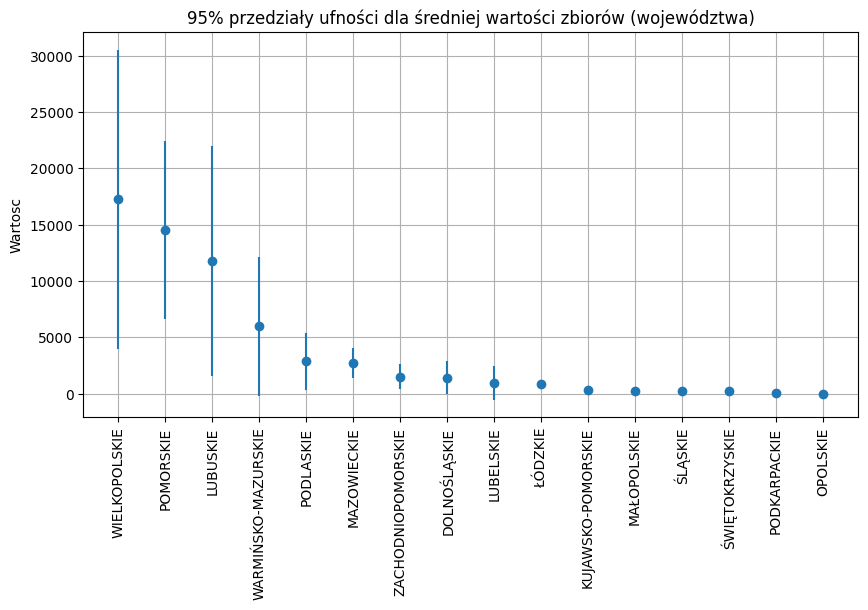

In [21]:
plt.figure(figsize=(10,5))
plt.errorbar(
    ci_wartosc["Region"],
    ci_wartosc["Średnia Wartosc"],
    yerr=[
        ci_wartosc["Średnia Wartosc"] - ci_wartosc["CI 95% dolna"],
        ci_wartosc["CI 95% górna"] - ci_wartosc["Średnia Wartosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej wartości zbiorów (województwa)")
plt.ylabel("Wartosc")
plt.grid(True)
plt.show()


#Wielkopolskie, Pomorskie i Lubuskie osiągają zdecydowanie najwyższe średnie wartości zbiorów, a szerokie przedziały ufności wskazują na duże wahania w poziomie wartości w czasie lub pomiędzy obserwacjami. Warmińsko-Mazurskie i Podlaskie zajmują pozycję pośrednią, z umiarkowaną wartością i względnie stabilnymi przedziałami. Najniższe średnie wartości zbiorów odnotowano w województwach takich jak Opolskie, Podkarpackie, Śląskie oraz Świętokrzyskie, gdzie zarówno poziom wartości, jak i zmienność są niewielkie.

#W celu wyznaczenia przedziałów predykcji dla ilości oraz wartości zbiorów grzybów i owoców leśnych oszacowano modele regresji liniowej metodą najmniejszych kwadratów. Jako zmienne objaśniające uwzględniono liczbę pożarów, poziom dewastacji, wskaźniki zanieczyszczeń, zatrudnienie oraz powierzchnię lasów, a także efekty stałe województw i trend czasowy. Na podstawie oszacowanych modeli wyznaczono 95% przedziały predykcji dla pojedynczych obserwacji, co umożliwiło ocenę niepewności prognozowanej ilości i wartości zbiorów w poszczególnych regionach.

In [23]:
pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 5.8 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.6 MB 5.0 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 5.8 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 6.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 6.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.8 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ----------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import statsmodels.formula.api as smf
import pandas as pd

# MODEL REGRESJI
model_ilosc = smf.ols(
    "Ilosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_ilosc.summary())

# PREDYKCJA + PRZEDZIAŁY PREDYKCJI
pred_ilosc = model_ilosc.get_prediction(df_all).summary_frame(alpha=0.05)

ilosc_out = df_all[["Region", "Year", "Ilosc"]].copy()
ilosc_out["y_hat"] = pred_ilosc["mean"]
ilosc_out["PI 95% dolna"] = pred_ilosc["obs_ci_lower"]
ilosc_out["PI 95% gorna"] = pred_ilosc["obs_ci_upper"]

print(ilosc_out.head())


                            OLS Regression Results                            
Dep. Variable:                  Ilosc   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     8.104
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           9.71e-11
Time:                        18:30:23   Log-Likelihood:                -557.44
No. Observations:                  80   AIC:                             1163.
Df Residuals:                      56   BIC:                             1220.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [25]:
model_wartosc = smf.ols(
    "Wartosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_wartosc.summary())

pred_wartosc = model_wartosc.get_prediction(df_all).summary_frame(alpha=0.05)

wartosc_out = df_all[["Region", "Year", "Wartosc"]].copy()
wartosc_out["y_hat"] = pred_wartosc["mean"]
wartosc_out["PI 95% dolna"] = pred_wartosc["obs_ci_lower"]
wartosc_out["PI 95% gorna"] = pred_wartosc["obs_ci_upper"]

print(wartosc_out.head())


                            OLS Regression Results                            
Dep. Variable:                Wartosc   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     7.110
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           1.13e-09
Time:                        18:33:42   Log-Likelihood:                -761.29
No. Observations:                  80   AIC:                             1571.
Df Residuals:                      56   BIC:                             1628.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
# Uśrednione PI per województwo

ilosc_region_pi = ilosc_out.groupby("Region").agg({
    "y_hat": "mean",
    "PI 95% dolna": "mean",
    "PI 95% gorna": "mean"
}).reset_index()

print(ilosc_region_pi)



                 Region        y_hat  PI 95% dolna  PI 95% gorna
0          DOLNOŚLĄSKIE   142.600003   -547.661210    832.861216
1    KUJAWSKO-POMORSKIE    30.400002   -655.872933    716.672937
2             LUBELSKIE    47.600003   -643.546017    738.746023
3              LUBUSKIE   804.600001    119.045663   1490.154340
4           MAZOWIECKIE   251.200001   -512.383046   1014.783048
5           MAŁOPOLSKIE    18.400002   -682.047435    718.847439
6              OPOLSKIE     0.000002   -697.297515    697.297519
7          PODKARPACKIE     2.400003   -688.559957    693.359963
8             PODLASKIE   167.600001   -530.674940    865.874942
9             POMORSKIE  1125.000003    435.303340   1814.696667
10  WARMIŃSKO-MAZURSKIE   356.200002   -337.668064   1050.068069
11        WIELKOPOLSKIE  1576.600002    871.119118   2282.080886
12   ZACHODNIOPOMORSKIE   125.200001   -572.918404    823.318406
13              ŁÓDZKIE   108.000002   -608.797452    824.797456
14              ŚLĄSKIE  

In [29]:
wartosc_region_pi = wartosc_out.groupby("Region").agg({
    "y_hat": "mean",
    "PI 95% dolna": "mean",
    "PI 95% gorna": "mean"
}).reset_index()

print(wartosc_region_pi)


                 Region         y_hat  PI 95% dolna  PI 95% gorna
0          DOLNOŚLĄSKIE   1417.960031  -7405.540230  10241.460293
1    KUJAWSKO-POMORSKIE    313.020021  -8459.498709   9085.538751
2             LUBELSKIE    969.600026  -7865.210580   9804.410632
3              LUBUSKIE  11741.560013   2978.226989  20504.893036
4           MAZOWIECKIE   2741.580025  -7019.181678  12502.341728
5           MAŁOPOLSKIE    239.440020  -8714.269130   9193.149170
6              OPOLSKIE      0.000022  -8913.444202   8913.444246
7          PODKARPACKIE     29.600025  -8802.832204   8862.032254
8             PODLASKIE   2884.500008  -6041.438472  11810.438488
9             POMORSKIE  14531.520031   5715.236322  23347.803741
10  WARMIŃSKO-MAZURSKIE   5970.500018  -2899.106081  14840.106117
11        WIELKOPOLSKIE  17257.020022   8238.969108  26275.070937
12   ZACHODNIOPOMORSKIE   1518.340011  -7405.597498  10442.277519
13              ŁÓDZKIE    833.880030  -8328.828814   9996.588874
14        

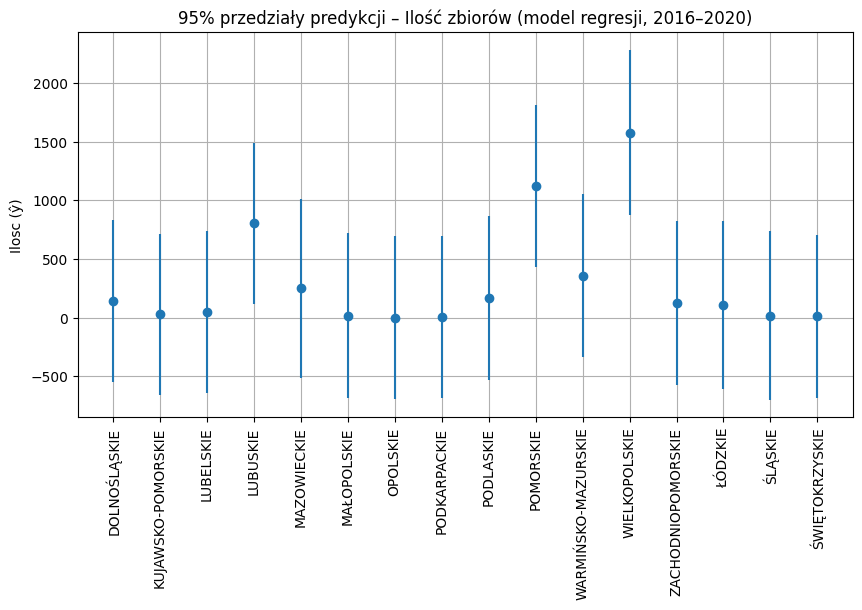

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    ilosc_region_pi["Region"],
    ilosc_region_pi["y_hat"],
    yerr=[
        ilosc_region_pi["y_hat"] - ilosc_region_pi["PI 95% dolna"],
        ilosc_region_pi["PI 95% gorna"] - ilosc_region_pi["y_hat"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały predykcji – Ilość zbiorów (model regresji, 2016–2020)")
plt.ylabel("Ilosc (ŷ)")
plt.grid(True)
plt.show()


#Wielkopolskie i Pomorskie charakteryzują się najwyższymi prognozowanymi wartościami ilości zbiorów, co sugeruje, że model identyfikuje te regiony jako obszary o największej przyszłej aktywności zbiorów. Lubuskie i Warmińsko-Mazurskie również osiągają relatywnie wysokie wartości prognoz, jednak towarzyszą im szerokie przedziały predykcji, co wskazuje na podwyższony poziom niepewności prognozy. W województwach takich jak Opolskie, Podkarpackie, Małopolskie i Śląskie prognozowane wartości są niskie lub bliskie zera, a przedziały predykcji obejmują również wartości ujemne, co świadczy o dużej zmienności danych i ograniczonej precyzji modelu w tych regionach.

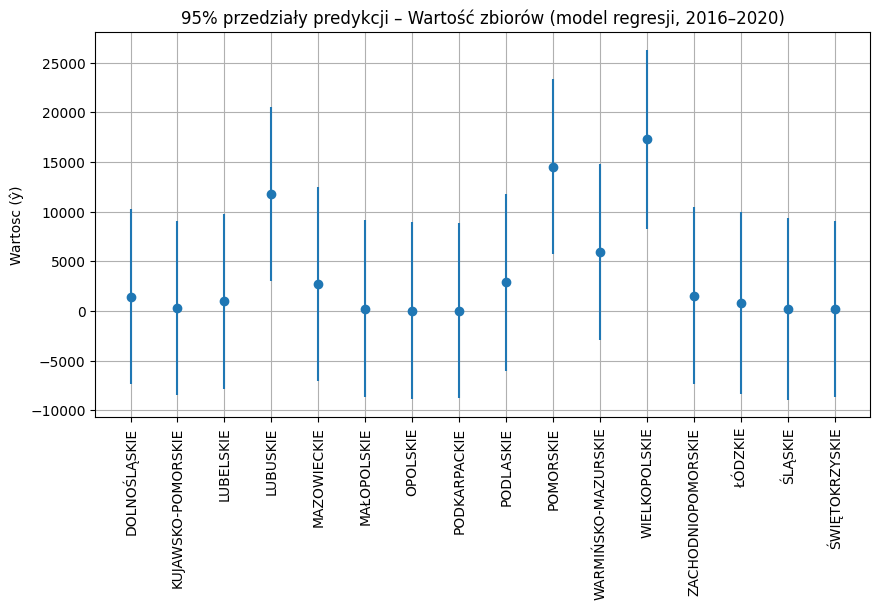

In [31]:
plt.figure(figsize=(10,5))
plt.errorbar(
    wartosc_region_pi["Region"],
    wartosc_region_pi["y_hat"],
    yerr=[
        wartosc_region_pi["y_hat"] - wartosc_region_pi["PI 95% dolna"],
        wartosc_region_pi["PI 95% gorna"] - wartosc_region_pi["y_hat"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały predykcji – Wartość zbiorów (model regresji, 2016–2020)")
plt.ylabel("Wartosc (ŷ)")
plt.grid(True)
plt.show()


#Najwyższe prognozowane wartości występują w województwach Wielkopolskim i Pomorskim, co potwierdza ich dominującą pozycję pod względem potencjału ekonomicznego zbiorów. Lubuskie oraz Warmińsko-Mazurskie osiągają umiarkowanie wysokie prognozy, jednak z bardzo szerokimi przedziałami predykcji, co wskazuje na znaczne wahania historyczne lub ograniczoną stabilność danych. W regionach takich jak Opolskie, Podkarpackie, Małopolskie, Śląskie i Świętokrzyskie wartości prognoz są niskie, a dolne granice przedziałów predykcji często przyjmują wartości ujemne, co sugeruje, że model ma trudności z precyzyjnym oszacowaniem wartości w obszarach o niskiej aktywności ekonomicznej.

#Dwuczynnikowa analiza wariancji (ANOVA) służy do oceny, czy średnie wartości zmiennej zależnej różnią się istotnie pomiędzy grupami wyznaczonymi przez dwa czynniki: województwo oraz rok. Test pozwala jednocześnie ocenić wpływ zróżnicowania przestrzennego i czasowego na ilość oraz wartość zbiorów. Metoda zakłada w przybliżeniu normalność rozkładu reszt oraz jednorodność wariancji w porównywanych grupach.

#Czy istnieją istotne różnice między województwami oraz między latami w zakresie Ilosc i Wartosc?

In [33]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ILOŚĆ
anova_ilosc_model = smf.ols("Ilosc ~ C(Region) + C(Year)", data=df_all).fit()
anova_ilosc = sm.stats.anova_lm(anova_ilosc_model, typ=2)
print("ANOVA – ILOŚĆ:\n", anova_ilosc)

# WARTOŚĆ
anova_wartosc_model = smf.ols("Wartosc ~ C(Region) + C(Year)", data=df_all).fit()
anova_wartosc = sm.stats.anova_lm(anova_wartosc_model, typ=2)
print("\nANOVA – WARTOŚĆ:\n", anova_wartosc)


ANOVA – ILOŚĆ:
                sum_sq    df          F        PR(>F)
C(Region)  16187460.2  15.0  11.159079  2.935187e-12
C(Year)      880183.8   4.0   2.275382  7.155396e-02
Residual    5802435.8  60.0        NaN           NaN

ANOVA – WARTOŚĆ:
                  sum_sq    df          F        PR(>F)
C(Region)  2.364178e+09  15.0  10.606802  8.211657e-12
C(Year)    1.289452e+08   4.0   2.169405  8.326636e-02
Residual   8.915707e+08  60.0        NaN           NaN


#Analiza ANOVA wykazała, że czynnik region ma istotny statystycznie wpływ zarówno na zmienną ILOŚĆ (F = 11,16; p = 2,94·10⁻¹²), jak i na zmienną WARTOŚĆ (F = 10,61; p = 8,21·10⁻¹²). Natomiast czynnik roku nie wykazuje istotnego wpływu ani na ILOŚĆ (F = 2,28; p = 0,072), ani na WARTOŚĆ (F = 2,17; p = 0,083).

#Regresja liniowa metodą najmniejszych kwadratów (OLS) umożliwia ocenę zależności pomiędzy zmienną zależną (ilość lub wartość zbiorów) a zestawem zmiennych objaśniających, takich jak poziom zanieczyszczeń, liczba pożarów, powierzchnia lasów. Metoda pozwala określić kierunek i siłę wpływu poszczególnych czynników oraz oszacować zdolność modelu do wyjaśniania zmienności badanej zmiennej.

#Które czynniki rzeczywiście wpływają na ilość i wartość zbiorów?

In [34]:
# MODEL ILOŚĆ
model_ilosc = smf.ols(
    "Ilosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_ilosc.summary())


# MODEL WARTOŚĆ
model_wartosc = smf.ols(
    "Wartosc ~ Pozary + Dewastacja + Za_gaz + Q('Za-pyl') + "
    "Zatrudnienie + P_lasy + P_lasy_ch + C(Region) + Year",
    data=df_all
).fit()

print(model_wartosc.summary())


                            OLS Regression Results                            
Dep. Variable:                  Ilosc   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     8.104
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           9.71e-11
Time:                        21:16:17   Log-Likelihood:                -557.44
No. Observations:                  80   AIC:                             1163.
Df Residuals:                      56   BIC:                             1220.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

#Na podstawie przeprowadzonych modeli regresji można stwierdzić, że pomimo wysokiego stopnia dopasowania modeli do danych, istotny i stabilny wpływ na poziom zarówno ilości, jak i wartości wykazuje wyłącznie zmienna „Za-pyl”. Pozostałe czynniki, w tym zróżnicowanie regionalne oraz czynnik czasowy (rok), nie wykazują istotnego wpływu statystycznego w ramach przyjętej specyfikacji modeli.

In [43]:
#F-test istotności modelu
#Dla ilosc

print("F-statistic (Ilosc):", model_ilosc.fvalue)
print("p-value (Ilosc):", model_ilosc.f_pvalue)

#Dla wartosc
print("F-statistic (Wartosc):", model_wartosc.fvalue)
print("p-value (Wartosc):", model_wartosc.f_pvalue)



F-statistic (Ilosc): 8.10391780272848
p-value (Ilosc): 9.707604113868644e-11
F-statistic (Wartosc): 7.1103941851312165
p-value (Wartosc): 1.131165367346617e-09


#Test F istotności całego modelu wykazał, że oba modele regresji są statystycznie istotne. Dla zmiennej ILOŚĆ uzyskano F = 8,10; p = 9,71·10⁻¹¹, co oznacza, że zestaw zmiennych objaśniających istotnie wyjaśnia zmienność tej zmiennej. Analogicznie, dla zmiennej WARTOŚĆ wartość F = 7,11; p = 1,13·10⁻⁹ potwierdza istotność statystyczną modelu jako całości. Oznacza to, że w obu przypadkach modele mają istotną zdolność wyjaśniania badanych zmiennych.

In [44]:
#Testy t (istotność współczynników w OLS)

#Testy t dla ilosc

t_ilosc = pd.DataFrame({
    "coef": model_ilosc.params,
    "std_err": model_ilosc.bse,
    "t": model_ilosc.tvalues,
    "p_value": model_ilosc.pvalues
}).sort_values("p_value")

print(t_ilosc.head(20))  # 20 najmniejszych p-value


#Testy t dla wartosc

t_wartosc = pd.DataFrame({
    "coef": model_wartosc.params,
    "std_err": model_wartosc.bse,
    "t": model_wartosc.tvalues,
    "p_value": model_wartosc.pvalues
}).sort_values("p_value")

print(t_wartosc.head(20))


                                         coef       std_err         t  \
Q('Za-pyl')                          0.239884      0.111513  2.151176   
Zatrudnienie                       133.345655     74.001864  1.801923   
C(Region)[T.LUBUSKIE]             1174.533172    795.766481  1.475977   
Pozary                              -0.227737      0.212979 -1.069295   
Dewastacja                         -51.577648     53.962051 -0.955813   
C(Region)[T.ŚLĄSKIE]             -2356.037202   3314.343237 -0.710861   
Za_gaz                              -0.000025      0.000041 -0.608249   
Year                               -30.531747     50.395487 -0.605843   
C(Region)[T.OPOLSKIE]              535.641241    936.095817  0.572208   
Intercept                        56331.750077  98918.266768  0.569478   
C(Region)[T.KUJAWSKO-POMORSKIE]   -811.607447   1665.165146 -0.487404   
C(Region)[T.MAŁOPOLSKIE]         -5318.165846  10945.566694 -0.485874   
C(Region)[T.MAZOWIECKIE]        -10147.193407  2165

#Analiza istotności parametrów modeli regresji wykazała, że jedyną zmienną o istotnym wpływie statystycznym na poziom zarówno ILOŚCI, jak i WARTOŚCI jest „Za-pyl” (dla ILOŚCI: β = 0,240; t = 2,15; p = 0,036; dla WARTOŚCI: β = 3,095; t = 2,17; p = 0,034). Pozostałe zmienne, w tym zatrudnienie, pożary, dewastacja, rok oraz efekty regionalne, nie osiągnęły istotności statystycznej (p > 0,05), co wskazuje na brak ich jednoznacznego wpływu na badane zmienne w ramach przyjętej specyfikacji modeli.

#Test Kruskala–Wallisa jest nieparametrycznym odpowiednikiem jednoczynnikowej analizy wariancji i służy do porównywania rozkładów zmiennej ilościowej pomiędzy więcej niż dwiema grupami. W badaniu został wykorzystany do oceny, czy rozkłady ilości i wartości zbiorów różnią się istotnie pomiędzy województwami, bez konieczności spełnienia założeń o normalności rozkładu i jednorodności wariancji.

#Czy rozkłady Ilosc i Wartosc różnią się między województwami, nawet bez założeń normalności?

In [47]:
#Kruskal dla ilosc 

from scipy.stats import kruskal

groups_ilosc = [g["Ilosc"].values for _, g in df_all.groupby("Region")]
kw_ilosc = kruskal(*groups_ilosc)
print("Kruskal–Wallis – ILOŚĆ:", kw_ilosc)

#Kruskal dla wartosc

groups_wartosc = [g["Wartosc"].values for _, g in df_all.groupby("Region")]
kw_wartosc = kruskal(*groups_wartosc)
print("Kruskal–Wallis – WARTOŚĆ:", kw_wartosc)

Kruskal–Wallis – ILOŚĆ: KruskalResult(statistic=np.float64(71.4863606495823), pvalue=np.float64(2.424814761318147e-09))
Kruskal–Wallis – WARTOŚĆ: KruskalResult(statistic=np.float64(72.13556872176923), pvalue=np.float64(1.8553305678113666e-09))


#Test Kruskala–Wallisa wykazał istotne statystycznie różnice pomiędzy regionami zarówno dla zmiennej ILOŚĆ (H = 71,49; p = 2,42·10⁻⁹), jak i dla zmiennej WARTOŚĆ (H = 72,14; p = 1,86·10⁻⁹). Oznacza to, że rozkłady obu zmiennych istotnie różnią się pomiędzy analizowanymi grupami.